# Análisis Estadístico Descriptivo — Encuesta de Telefonía Móvil
## Alineado al Temario de Estadística Descriptiva (Unidades 1.1–1.5)

**Contexto:** Encuesta aplicada a 511 estudiantes universitarios de carreras STEM (Ciencia de Datos, Ingeniería en Sistemas, Inteligencia Artificial) sobre sus hábitos y preferencias de telefonía móvil.

**Objetivo:** Aplicar las herramientas de estadística descriptiva del temario para extraer insights accionables sobre el perfil tecnológico estudiantil.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 120,
})
sns.set_style("whitegrid")
print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 0. Carga y Limpieza de Datos

In [33]:
df = pd.read_csv('csv.csv')
print(f"Dimensiones originales: {df.shape}")
df.head()

Dimensiones originales: (511, 17)


,Marca temporal,Dirección de correo electrónico,¿En qué semestre te encuentras actualmente?,¿Qué carrera estudias?,¿Eres alumno regular?,Procedencia (dónde naciste),¿Tienes hermanos?,¿Cuál es la marca de tu teléfono?,Modelo del teléfono,Capacidad del teléfono,Plan o prepago del teléfono,Tiempo que llevas con tu teléfono,Tu teléfono es,Género,¿Trabajas?,Edad,¿Qué teléfono te gustaría tener?
0,3/9/2026 17:30:44,fespinozagarcia0105@gmail.com,Tercero,Ciencia de Datos,NaN,Estado de México,NaN,Honor,Honor x7a,128 GB,Plan,Entre 2 y 3 años,Nuevo,Mujer,Sí,21,NaN
1,3/9/2026 18:02:01,gisellemerino2702@gmail.com,Tercero,Ciencia de Datos,NaN,Estado de México,NaN,Apple,15 pro max,256 GB,Prepago,Entre 6 meses y 1 año,Nuevo,Mujer,No,21,NaN
2,3/9/2026 18:19:25,mildredcaravantes@gmail.com,Primero,Ciencia de Datos,NaN,Estado de México,NaN,Apple,iphone 16 pro max,256 GB,Plan,Entre 1 y 2 años,Nuevo,Mujer,No,20,NaN
3,3/9/2026 18:37:08,garcia.hernandez.edgar.alessandro@gmail.com,Tercero,Ciencia de Datos,NaN,CDMX,NaN,Apple,iPhone 16 Pro Max,256 GB,Plan,Entre 1 y 2 años,Nuevo,Hombre,No,19,NaN
4,3/9/2026 20:56:29,diegobus022@gmail.com,Tercero,Ciencia de Datos,NaN,Otro,NaN,Apple,iPhone 13 Pro max,512 GB,Prepago,Entre 1 y 2 años,Segunda mano,Hombre,No,19,NaN


In [34]:
# Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 511 entries, 0 to 510
Data columns (total 17 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   Marca temporal                                511 non-null    str  
 1   Dirección de correo electrónico               511 non-null    str  
 2   ¿En qué semestre te encuentras actualmente?   511 non-null    str  
 3   ¿Qué carrera estudias?                        511 non-null    str  
 4   ¿Eres alumno regular?                         482 non-null    str  
 5   Procedencia  (dónde naciste)                  511 non-null    str  
 6   ¿Tienes hermanos?                             482 non-null    str  
 7   ¿Cuál es la marca de tu teléfono?             511 non-null    str  
 8   Modelo del teléfono                           511 non-null    str  
 9   Capacidad del teléfono                        511 non-null    str  
 10  Plan o prepago del teléfo

In [35]:
# Análisis de valores nulos
total = len(df)
nulls = df.isnull().sum()
nulls_pct = (nulls / total) * 100
pd.DataFrame({"Nulos": nulls, "%": nulls_pct.round(1)})

,Nulos,%
Marca temporal,0,0.0
Dirección de correo electrónico,0,0.0
¿En qué semestre te encuentras actualmente?,0,0.0
¿Qué carrera estudias?,0,0.0
¿Eres alumno regular?,29,5.7
Procedencia (dónde naciste),0,0.0
¿Tienes hermanos?,29,5.7
¿Cuál es la marca de tu teléfono?,0,0.0
Modelo del teléfono,0,0.0
Capacidad del teléfono,0,0.0


In [36]:
# Renombrar columnas para facilidad de manejo
col_map = {
    df.columns[2]: 'Semestre',
    df.columns[3]: 'Carrera',
    df.columns[4]: 'AlumnoRegular',
    df.columns[5]: 'Procedencia',
    df.columns[6]: 'TieneHermanos',
    df.columns[7]: 'Marca',
    df.columns[8]: 'Modelo',
    df.columns[9]: 'Capacidad',
    df.columns[10]: 'PlanPrepago',
    df.columns[11]: 'TiempoTelefono',
    df.columns[12]: 'NuevoUsado',
    df.columns[13]: 'Genero',
    df.columns[14]: 'Trabaja',
    df.columns[15]: 'Edad',
    df.columns[16]: 'TelefonoDeseado',
}
df.rename(columns=col_map, inplace=True)

# Limpieza
df = df.dropna(how='all')
df = df.drop(columns=['Marca temporal', 'Dirección de correo electrónico'], errors='ignore')
df = df[df['Marca'].notna() & (df['Marca'].str.strip() != '')]

# Limpiar strings
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

print(f"Registros válidos después de limpieza: {len(df)}")

Registros válidos después de limpieza: 511


### Feature Engineering

In [37]:
# Extraer capacidad numérica (GB)
df['Capacidad_GB'] = df['Capacidad'].str.extract(r'(\d+)').astype(float)
df.loc[df['Capacidad'].str.contains('TB', case=False, na=False), 'Capacidad_GB'] *= 1024

# Edad numérica
df['Edad_num'] = df['Edad'].apply(lambda x: 24 if '24' in str(x) else pd.to_numeric(x, errors='coerce'))

# Grupo de edad
df['GrupoEdad'] = pd.cut(df['Edad_num'], bins=[16,19,21,24,30],
                          labels=['17-19','20-21','22-24','25+'], right=True)

# Semestre numérico
sem_map = {'Primero':1,'Segundo':2,'Tercero':3,'Cuarto':4,'Quinto':5,'Sexto':6,'Séptimo':7,'Octavo':8}
df['Semestre_num'] = df['Semestre'].map(sem_map)

# Procedencia agrupada
df['Procedencia_cat'] = df['Procedencia'].apply(
    lambda x: 'CDMX' if 'CDMX' in str(x) else ('Edo. México' if 'Estado' in str(x) else 'Otro estado'))

# Marca simplificada
top_marcas = df['Marca'].value_counts().head(6).index.tolist()
df['Marca_cat'] = df['Marca'].apply(lambda x: x if x in top_marcas else 'Otra')

# Capacidad categórica
df['Capacidad_cat'] = pd.cut(df['Capacidad_GB'], bins=[0,64,128,256,2048],
                              labels=['≤64 GB','128 GB','256 GB','≥512 GB'])

# Tiempo con teléfono (ordinal)
tiempo_map = {'Menos de 6 meses':1, 'Entre 6 meses y 1 año':2,
              'Entre 1 y 2 años':3, 'Entre 2 y 3 años':4, 'Más de 3 años':5}
df['Tiempo_num'] = df['TiempoTelefono'].map(tiempo_map)

print("✅ Feature engineering completado")
print(f"Variables numéricas: {df.select_dtypes(include='number').columns.tolist()}")
print(f"Variables categóricas: {df.select_dtypes(exclude='number').columns.tolist()}")

✅ Feature engineering completado
Variables numéricas: ['Capacidad_GB', 'Edad_num', 'Semestre_num', 'Tiempo_num']
Variables categóricas: ['Semestre', 'Carrera', 'AlumnoRegular', 'Procedencia', 'TieneHermanos', 'Marca', 'Modelo', 'Capacidad', 'PlanPrepago', 'TiempoTelefono', 'NuevoUsado', 'Genero', 'Trabaja', 'Edad', 'TelefonoDeseado', 'GrupoEdad', 'Procedencia_cat', 'Marca_cat', 'Capacidad_cat']


---
## 1.1 Elementos de la Estadística Descriptiva

### 1.1.1 Poblaciones, muestras y variabilidad

**Población objetivo:** Todos los estudiantes universitarios de carreras STEM en la zona metropolitana de la CDMX.

**Muestra:** 511 estudiantes que respondieron la encuesta, de las carreras de Ciencia de Datos, Ingeniería en Sistemas, Inteligencia Artificial y Automotriz.

**Tipo de muestreo:** No probabilístico por conveniencia (formulario enviado a grupos de clase).

**Variables recopiladas:** 15 variables que cubren datos demográficos (edad, género, procedencia), académicos (carrera, semestre, regularidad) y de consumo tecnológico (marca, modelo, capacidad, plan, antigüedad del teléfono).

In [38]:
# Composición de la muestra
print(f"Tamaño de muestra (n): {len(df)}")
print(f"\nDistribución por carrera:")
print(df['Carrera'].value_counts())
print(f"\nDistribución por género:")
print(df['Genero'].value_counts())
print(f"\nProcedencia:")
print(df['Procedencia_cat'].value_counts())

Tamaño de muestra (n): 511

Distribución por carrera:
Carrera
Ingeniería en Sistemas     267
Ciencia de Datos           165
Inteligencia Artificial     77
Automotriz                   2
Name: count, dtype: int64

Distribución por género:
Genero
Hombre    374
Mujer     137
Name: count, dtype: int64

Procedencia:
Procedencia_cat
CDMX           275
Edo. México    205
Otro estado     31
Name: count, dtype: int64


---
## 1.2 Descriptores Muestrales de Centralización y Dispersión

### 1.2.1 Media y mediana muestrales

Comparamos media y mediana para detectar asimetrías en las distribuciones:
- Si **media ≈ mediana**: distribución simétrica
- Si **media > mediana**: sesgo positivo (cola derecha)
- Si **media < mediana**: sesgo negativo (cola izquierda)

In [39]:
for var, name in [('Edad_num','Edad'), ('Capacidad_GB','Capacidad (GB)'), ('Semestre_num','Semestre')]:
    data = df[var].dropna()
    media = data.mean()
    mediana = data.median()
    sesgo = stats.skew(data)
    print(f"\n{'='*40}")
    print(f"{name}:")
    print(f"  Media (x̄): {media:.2f}")
    print(f"  Mediana (x̃): {mediana:.1f}")
    print(f"  Diferencia: {media-mediana:.2f}")
    print(f"  Coeficiente de asimetría: {sesgo:.3f}")
    if abs(sesgo) < 0.5:
        print(f"  → Distribución aprox. simétrica")
    elif sesgo > 0:
        print(f"  → Sesgo POSITIVO (cola derecha)")
    else:
        print(f"  → Sesgo NEGATIVO (cola izquierda)")


Edad:
  Media (x̄): 20.35
  Mediana (x̃): 20.0
  Diferencia: 0.35
  Coeficiente de asimetría: 0.565
  → Sesgo POSITIVO (cola derecha)

Capacidad (GB):
  Media (x̄): 220.68
  Mediana (x̃): 128.0
  Diferencia: 92.68
  Coeficiente de asimetría: 3.703
  → Sesgo POSITIVO (cola derecha)

Semestre:
  Media (x̄): 3.89
  Mediana (x̃): 4.0
  Diferencia: -0.11
  Coeficiente de asimetría: 0.503
  → Sesgo POSITIVO (cola derecha)


### 1.2.2 Unimodalidad y multimodalidad

Identificamos si las distribuciones tienen una sola moda (unimodal) o múltiples modas (multimodal), lo cual revela si hay subgrupos diferenciados en la población.

In [40]:
for var, name in [('Edad_num','Edad'), ('Capacidad_GB','Capacidad (GB)'), ('Semestre_num','Semestre')]:
    data = df[var].dropna()
    mode_vals = data.mode()
    freq_table = data.value_counts().head(5)
    print(f"\n{name}:")
    print(f"  Moda(s): {mode_vals.tolist()}")
    print(f"  Tabla de frecuencias (top 5):")
    print(freq_table)
    if len(mode_vals) > 1:
        print(f"  → MULTIMODAL")
    else:
        print(f"  → UNIMODAL")


Edad:
  Moda(s): [19]
  Tabla de frecuencias (top 5):
Edad_num
19    131
20    109
21     84
22     61
18     59
Name: count, dtype: int64
  → UNIMODAL

Capacidad (GB):
  Moda(s): [256.0]
  Tabla de frecuencias (top 5):
Capacidad_GB
256.0    195
128.0    182
64.0      57
512.0     51
32.0      18
Name: count, dtype: int64
  → UNIMODAL

Semestre:
  Moda(s): [4]
  Tabla de frecuencias (top 5):
Semestre_num
4    113
3    100
2    100
6     56
5     52
Name: count, dtype: int64
  → UNIMODAL


### 1.2.3 Varianza muestral y desviación estándar

La **varianza muestral** (s²) y la **desviación estándar** (s) cuantifican la dispersión de los datos alrededor de la media. Usamos el **coeficiente de variación** (CV = s/x̄ × 100%) para comparar dispersiones entre variables con distintas escalas.

In [41]:
results = []
for var, name in [('Edad_num','Edad'), ('Capacidad_GB','Capacidad (GB)'), ('Semestre_num','Semestre')]:
    data = df[var].dropna()
    results.append({
        'Variable': name,
        'n': len(data),
        'Media (x̄)': round(data.mean(), 2),
        'Varianza (s²)': round(data.var(ddof=1), 2),
        'Desv. Std (s)': round(data.std(ddof=1), 2),
        'CV (%)': round((data.std(ddof=1)/data.mean())*100, 1),
        'Mínimo': data.min(),
        'Máximo': data.max(),
        'Rango': data.max() - data.min()
    })

pd.DataFrame(results).set_index('Variable')

,n,Media (x̄),Varianza (s²),Desv. Std (s),CV (%),Mínimo,Máximo,Rango
Variable,,,,,,,,
Edad,511,20.35,2.97,1.72,8.5,17.0,24.0,7.0
Capacidad (GB),511,220.68,31433.79,177.30,80.3,32.0,2048.0,2016.0
Semestre,511,3.89,3.47,1.86,47.8,1.0,8.0,7.0


### 1.2.4 Intercuartiles

Los cuartiles dividen la distribución en 4 partes iguales. El **rango intercuartílico** (IQR = Q3 - Q1) es una medida de dispersión robusta a outliers.

In [42]:
for var, name in [('Edad_num','Edad'), ('Capacidad_GB','Capacidad (GB)')]:
    data = df[var].dropna()
    q1, q2, q3 = data.quantile([0.25, 0.50, 0.75])
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    outliers = data[(data < lim_inf) | (data > lim_sup)]

    print(f"\n{'='*50}")
    print(f"{name}:")
    print(f"  Q1 (25%): {q1}")
    print(f"  Q2 (50%, mediana): {q2}")
    print(f"  Q3 (75%): {q3}")
    print(f"  IQR = Q3 - Q1: {iqr}")
    print(f"  Cerca inferior [Q1 - 1.5·IQR]: {lim_inf:.1f}")
    print(f"  Cerca superior [Q3 + 1.5·IQR]: {lim_sup:.1f}")
    print(f"  Outliers detectados: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)")
    if len(outliers) > 0:
        print(f"  Valores atípicos: {sorted(outliers.unique())}")


Edad:
  Q1 (25%): 19.0
  Q2 (50%, mediana): 20.0
  Q3 (75%): 21.0
  IQR = Q3 - Q1: 2.0
  Cerca inferior [Q1 - 1.5·IQR]: 16.0
  Cerca superior [Q3 + 1.5·IQR]: 24.0
  Outliers detectados: 0 (0.0%)

Capacidad (GB):
  Q1 (25%): 128.0
  Q2 (50%, mediana): 128.0
  Q3 (75%): 256.0
  IQR = Q3 - Q1: 128.0
  Cerca inferior [Q1 - 1.5·IQR]: -64.0
  Cerca superior [Q3 + 1.5·IQR]: 448.0
  Outliers detectados: 59 (11.5%)
  Valores atípicos: [np.float64(512.0), np.float64(1024.0), np.float64(2048.0)]


---
## 1.3 Herramientas Gráficas para Observaciones Univariadas

### 1.3.1 Histogramas y elección de sus intervalos

Comparamos tres reglas para la elección del número de intervalos (bins):
- **Sturges:** k = ⌈log₂(n) + 1⌉ — buena para distribuciones simétricas
- **Freedman-Diaconis:** h = 2·IQR·n^(-1/3) — robusta a outliers
- **Scott:** h = 3.49·s·n^(-1/3) — óptima bajo normalidad

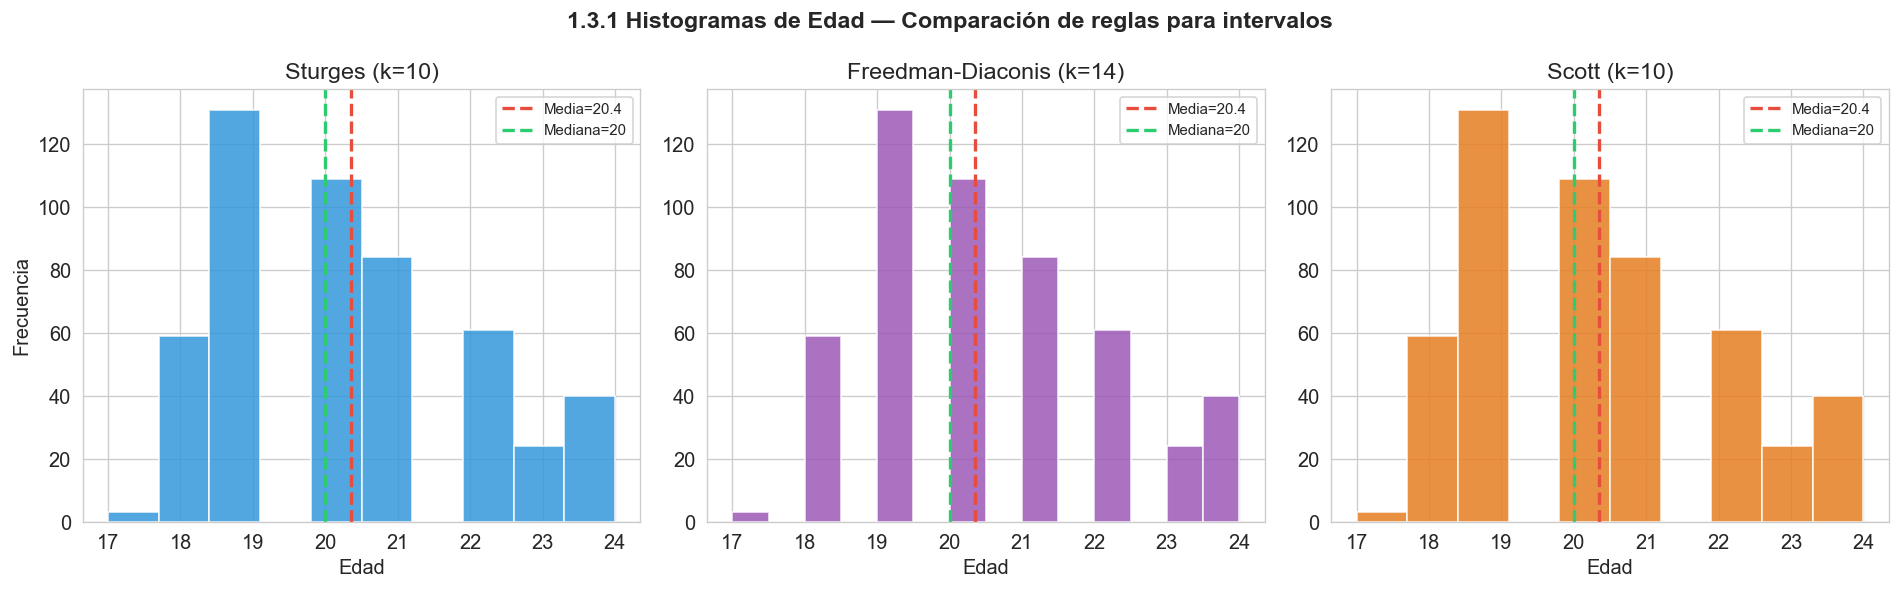

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
data_edad = df['Edad_num'].dropna()

# Sturges
k_sturges = int(np.ceil(np.log2(len(data_edad)) + 1))
axes[0].hist(data_edad, bins=k_sturges, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(data_edad.mean(), color='#e74c3c', linestyle='--', lw=2, label=f'Media={data_edad.mean():.1f}')
axes[0].axvline(data_edad.median(), color='#2ecc71', linestyle='--', lw=2, label=f'Mediana={data_edad.median():.0f}')
axes[0].set_title(f'Sturges (k={k_sturges})')
axes[0].set_xlabel('Edad'); axes[0].set_ylabel('Frecuencia'); axes[0].legend(fontsize=9)

# Freedman-Diaconis
iqr_e = np.subtract(*np.percentile(data_edad, [75, 25]))
h_fd = 2 * iqr_e / (len(data_edad)**(1/3))
k_fd = max(1, int(np.ceil((data_edad.max() - data_edad.min()) / h_fd)))
axes[1].hist(data_edad, bins=k_fd, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[1].axvline(data_edad.mean(), color='#e74c3c', linestyle='--', lw=2, label=f'Media={data_edad.mean():.1f}')
axes[1].axvline(data_edad.median(), color='#2ecc71', linestyle='--', lw=2, label=f'Mediana={data_edad.median():.0f}')
axes[1].set_title(f'Freedman-Diaconis (k={k_fd})')
axes[1].set_xlabel('Edad'); axes[1].legend(fontsize=9)

# Scott
h_scott = 3.49 * data_edad.std() / (len(data_edad)**(1/3))
k_scott = max(1, int(np.ceil((data_edad.max() - data_edad.min()) / h_scott)))
axes[2].hist(data_edad, bins=k_scott, color='#e67e22', edgecolor='white', alpha=0.85)
axes[2].axvline(data_edad.mean(), color='#e74c3c', linestyle='--', lw=2, label=f'Media={data_edad.mean():.1f}')
axes[2].axvline(data_edad.median(), color='#2ecc71', linestyle='--', lw=2, label=f'Mediana={data_edad.median():.0f}')
axes[2].set_title(f'Scott (k={k_scott})')
axes[2].set_xlabel('Edad'); axes[2].legend(fontsize=9)

plt.suptitle('1.3.1 Histogramas de Edad — Comparación de reglas para intervalos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

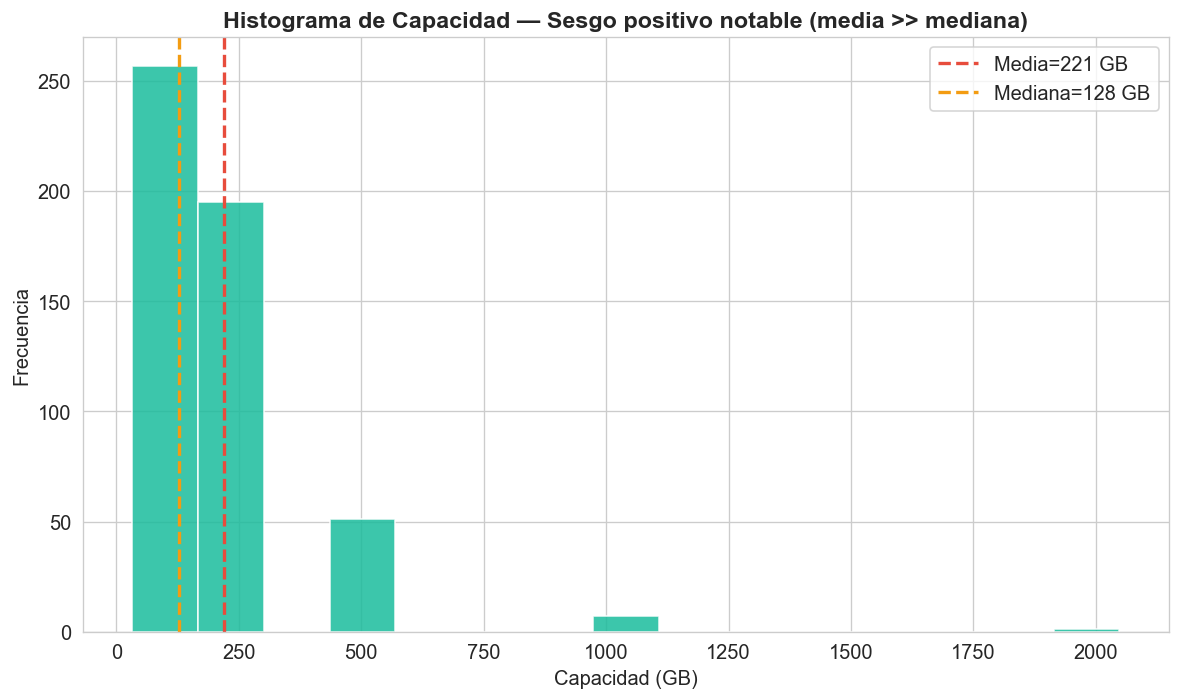

In [44]:
# Histograma de Capacidad — distribución con sesgo positivo
fig, ax = plt.subplots(figsize=(10, 6))
data_cap = df['Capacidad_GB'].dropna()
ax.hist(data_cap, bins=15, color='#1abc9c', edgecolor='white', alpha=0.85)
ax.axvline(data_cap.mean(), color='#e74c3c', linestyle='--', lw=2, label=f'Media={data_cap.mean():.0f} GB')
ax.axvline(data_cap.median(), color='#f39c12', linestyle='--', lw=2, label=f'Mediana={data_cap.median():.0f} GB')
ax.set_title('Histograma de Capacidad — Sesgo positivo notable (media >> mediana)', fontweight='bold')
ax.set_xlabel('Capacidad (GB)'); ax.set_ylabel('Frecuencia'); ax.legend()
plt.tight_layout(); plt.show()

### 1.3.2–1.3.3 Gráficas de caja y bigote

El **boxplot** (gráfica de caja y bigote) muestra simultáneamente:
- **Caja:** Q1 a Q3 (contiene el 50% central de los datos)
- **Línea central:** mediana (Q2)
- **Bigotes:** extienden hasta 1.5×IQR desde la caja
- **Puntos:** outliers fuera de los bigotes

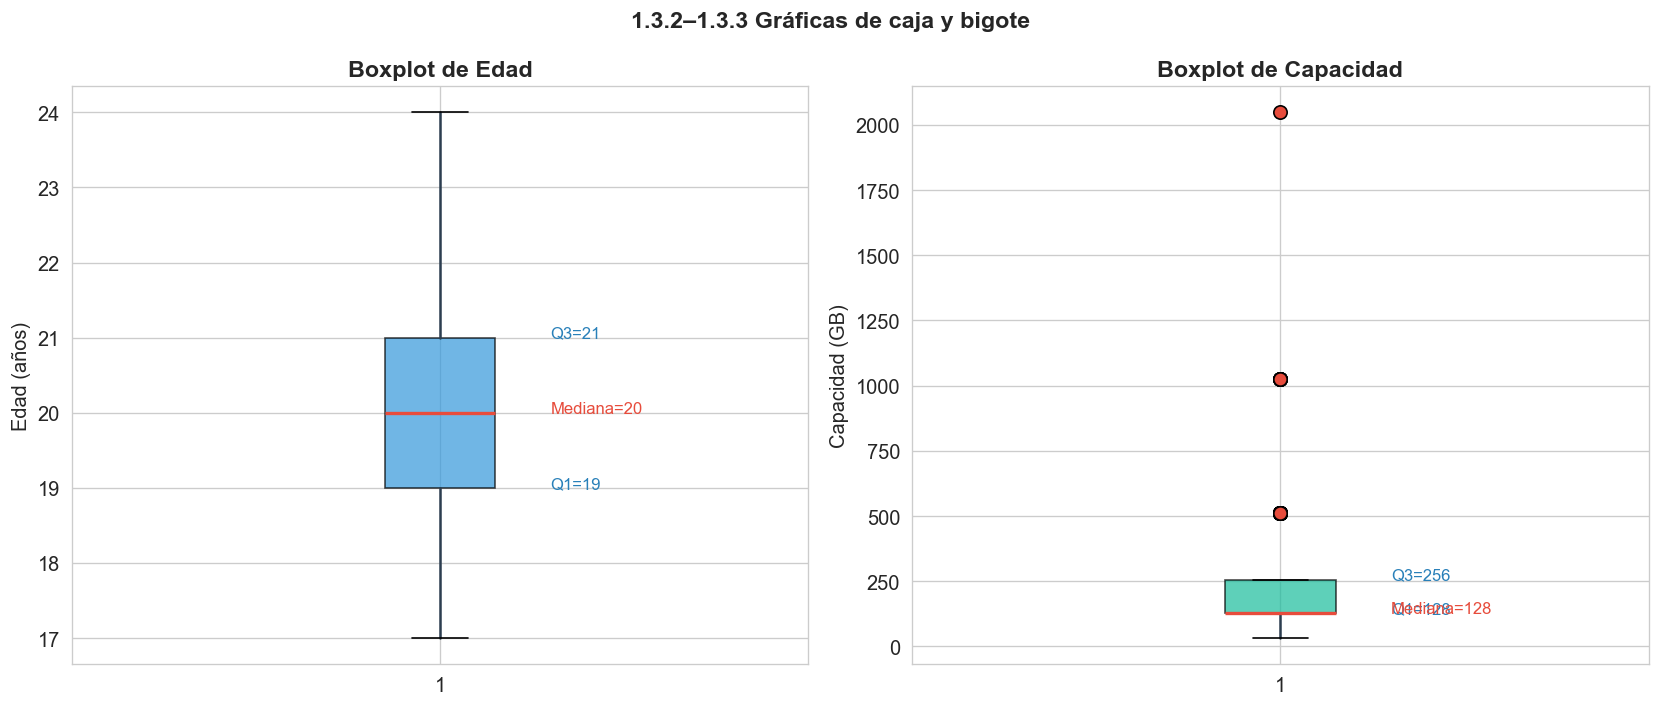

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bp1 = axes[0].boxplot(data_edad, vert=True, patch_artist=True,
            boxprops=dict(facecolor='#3498db', alpha=0.7),
            medianprops=dict(color='#e74c3c', linewidth=2),
            whiskerprops=dict(color='#2c3e50', linewidth=1.5),
            flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=8))
axes[0].set_title('Boxplot de Edad', fontweight='bold')
axes[0].set_ylabel('Edad (años)')
q1_e, q3_e = data_edad.quantile(0.25), data_edad.quantile(0.75)
axes[0].annotate(f'Q1={q1_e:.0f}', xy=(1.15, q1_e), fontsize=10, color='#2980b9')
axes[0].annotate(f'Mediana={data_edad.median():.0f}', xy=(1.15, data_edad.median()), fontsize=10, color='#e74c3c')
axes[0].annotate(f'Q3={q3_e:.0f}', xy=(1.15, q3_e), fontsize=10, color='#2980b9')

bp2 = axes[1].boxplot(data_cap, vert=True, patch_artist=True,
            boxprops=dict(facecolor='#1abc9c', alpha=0.7),
            medianprops=dict(color='#e74c3c', linewidth=2),
            whiskerprops=dict(color='#2c3e50', linewidth=1.5),
            flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=8))
axes[1].set_title('Boxplot de Capacidad', fontweight='bold')
axes[1].set_ylabel('Capacidad (GB)')
q1_c, q3_c = data_cap.quantile(0.25), data_cap.quantile(0.75)
axes[1].annotate(f'Q1={q1_c:.0f}', xy=(1.15, q1_c), fontsize=10, color='#2980b9')
axes[1].annotate(f'Mediana={data_cap.median():.0f}', xy=(1.15, data_cap.median()), fontsize=10, color='#e74c3c')
axes[1].annotate(f'Q3={q3_c:.0f}', xy=(1.15, q3_c), fontsize=10, color='#2980b9')

plt.suptitle('1.3.2–1.3.3 Gráficas de caja y bigote', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

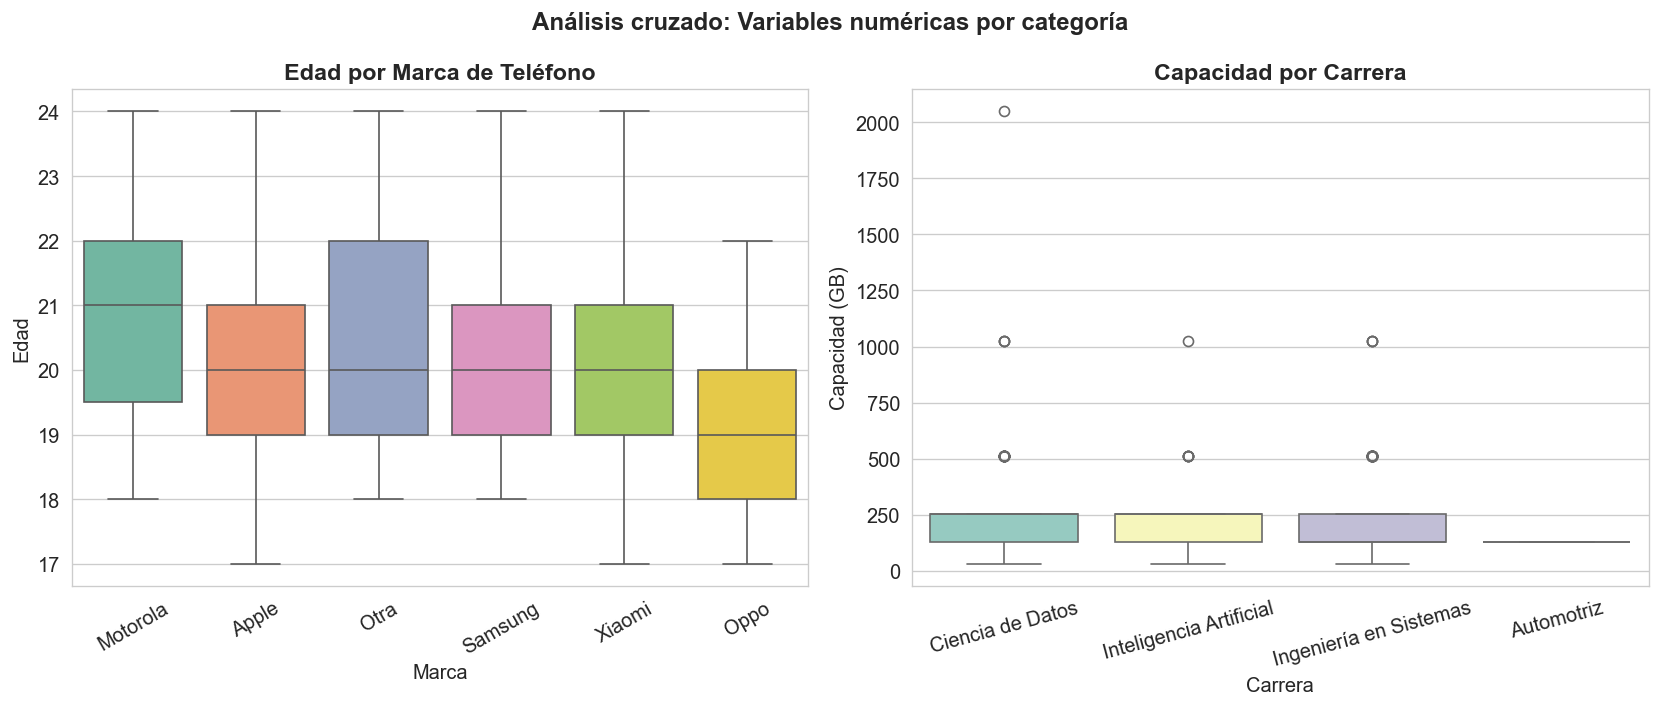

In [46]:
# Boxplots cruzados: variables numéricas por categoría
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

order_marca = df.groupby('Marca_cat')['Edad_num'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Marca_cat', y='Edad_num', order=order_marca, ax=axes[0], palette='Set2')
axes[0].set_title('Edad por Marca de Teléfono', fontweight='bold')
axes[0].set_xlabel('Marca'); axes[0].set_ylabel('Edad')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='Carrera', y='Capacidad_GB', ax=axes[1], palette='Set3')
axes[1].set_title('Capacidad por Carrera', fontweight='bold')
axes[1].set_xlabel('Carrera'); axes[1].set_ylabel('Capacidad (GB)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Análisis cruzado: Variables numéricas por categoría', fontweight='bold')
plt.tight_layout(); plt.show()

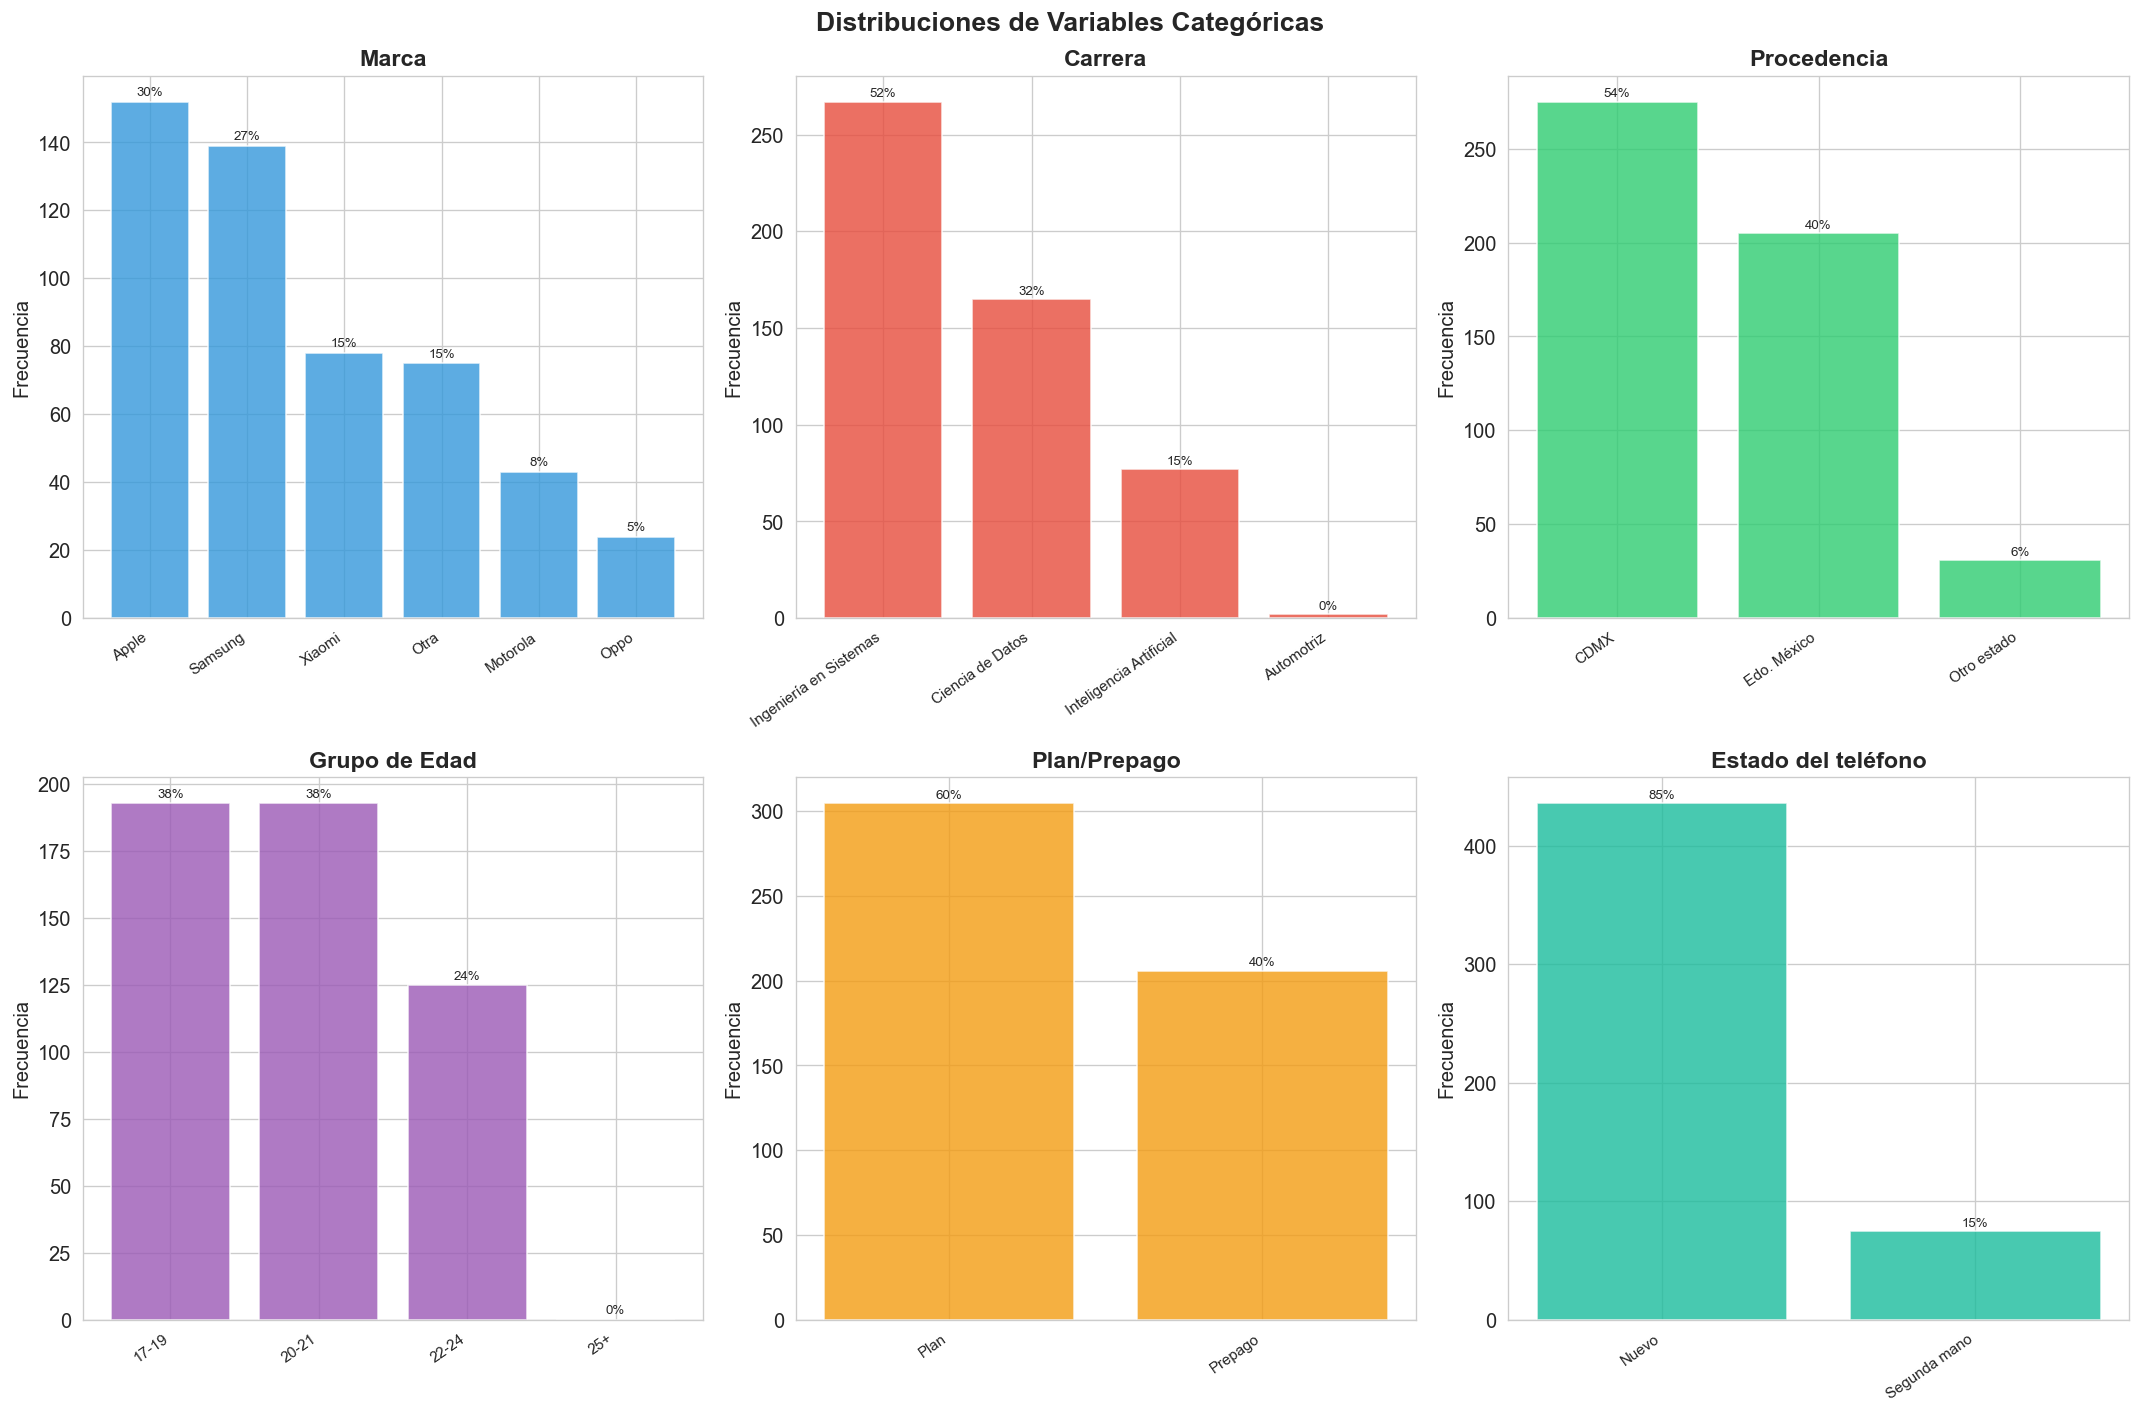

In [47]:
# Distribuciones de variables categóricas
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
cats = [('Marca_cat','Marca'), ('Carrera','Carrera'), ('Procedencia_cat','Procedencia'),
        ('GrupoEdad','Grupo de Edad'), ('PlanPrepago','Plan/Prepago'), ('NuevoUsado','Estado del teléfono')]
colors = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#f39c12','#1abc9c']

for ax, (col, title), color in zip(axes.flatten(), cats, colors):
    counts = df[col].value_counts()
    bars = ax.bar(range(len(counts)), counts.values, color=color, alpha=0.8, edgecolor='white')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=35, ha='right', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                f'{val/total*100:.0f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('Distribuciones de Variables Categóricas', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 1.4 Herramientas Gráficas para Observaciones Multivariadas

### 1.4.1 Representación de rasgos esenciales y proyecciones

La **matriz de dispersión** (scatter matrix) permite visualizar simultáneamente las relaciones entre todas las variables numéricas mediante proyecciones bidimensionales.

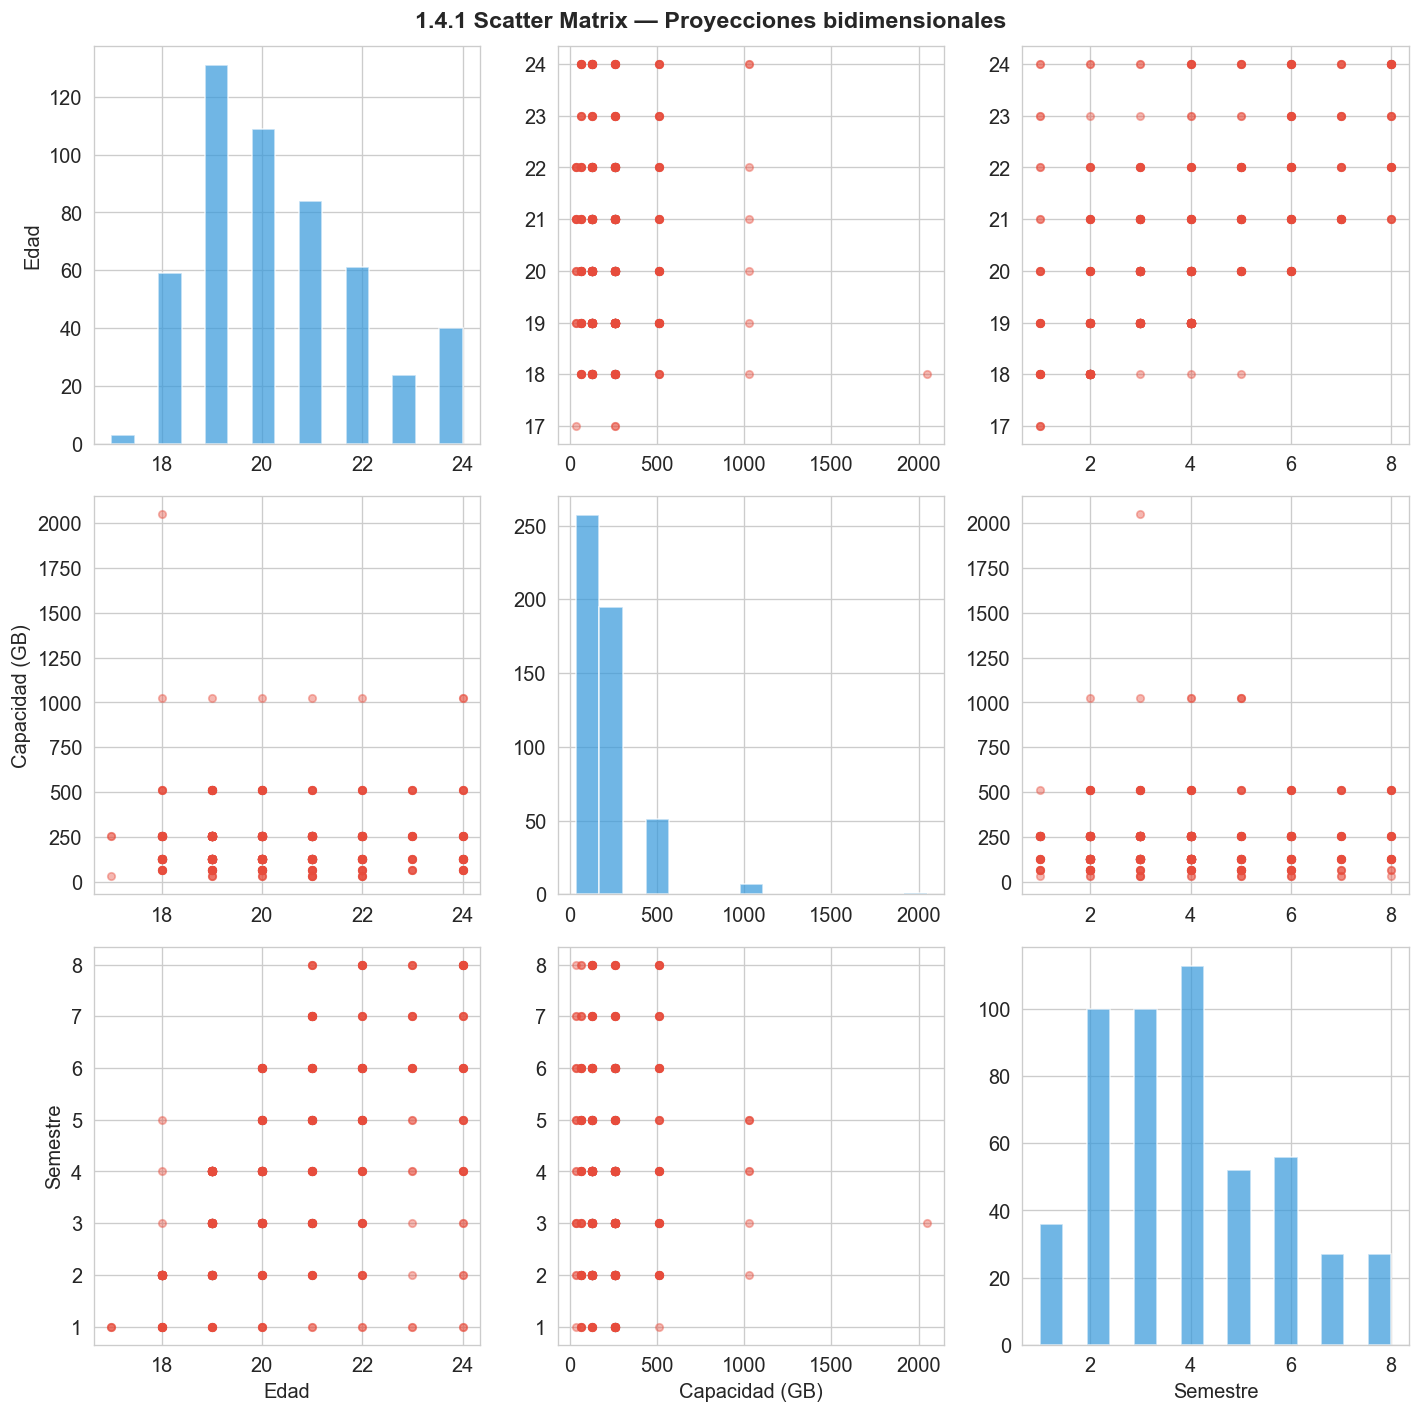

In [48]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
num_vars = ['Edad_num', 'Capacidad_GB', 'Semestre_num']
num_labels = ['Edad', 'Capacidad (GB)', 'Semestre']

for i in range(3):
    for j in range(3):
        ax = axes[i][j]
        if i == j:
            ax.hist(df[num_vars[i]].dropna(), bins=15, color='#3498db', alpha=0.7, edgecolor='white')
        else:
            ax.scatter(df[num_vars[j]], df[num_vars[i]], alpha=0.4, s=20, color='#e74c3c')
        if i == 2: ax.set_xlabel(num_labels[j])
        if j == 0: ax.set_ylabel(num_labels[i])

plt.suptitle('1.4.1 Scatter Matrix — Proyecciones bidimensionales', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 1.4.2 Representación de espacios de estados y sus proyecciones

El **espacio de estados** permite representar cada observación como un punto en un espacio multidimensional. Usamos color y tamaño para proyectar dimensiones adicionales.

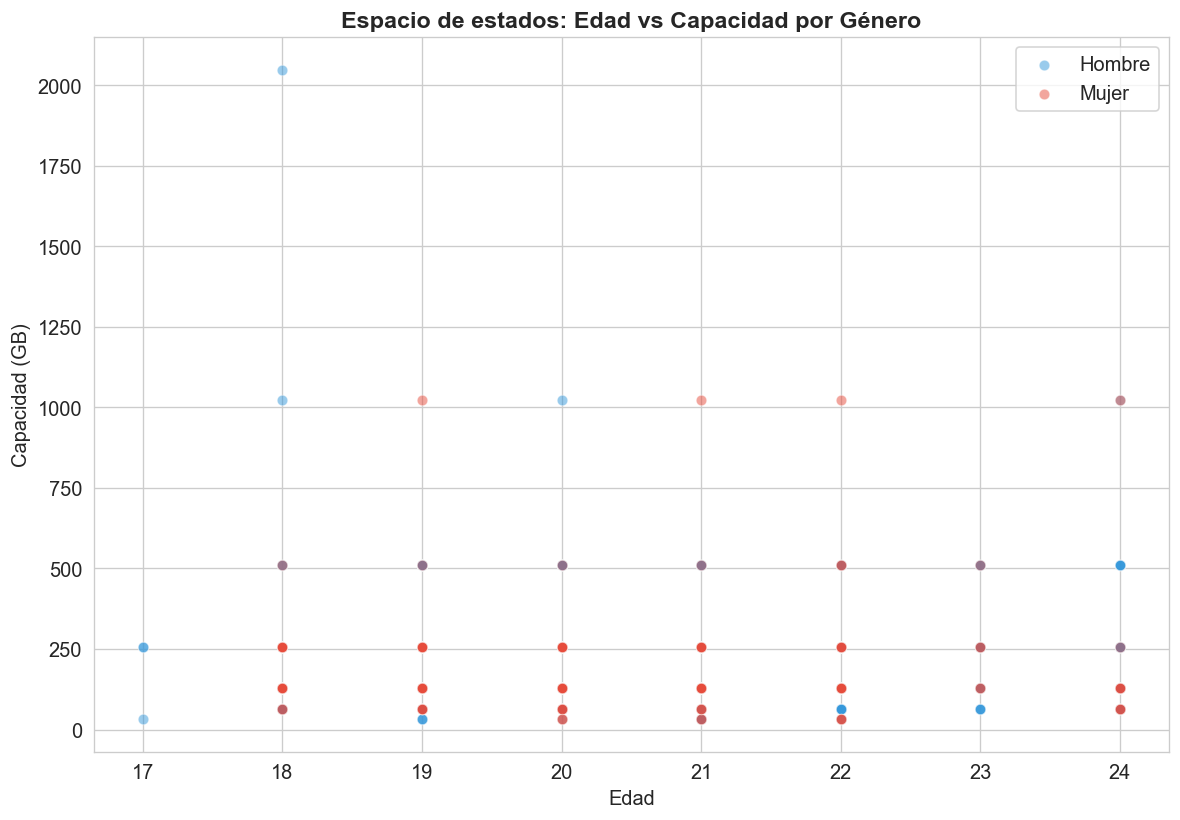

In [49]:
# Espacio de estados: Edad vs Capacidad, coloreado por Género
fig, ax = plt.subplots(figsize=(10, 7))
genero_colors = {'Hombre': '#3498db', 'Mujer': '#e74c3c'}
for g, color in genero_colors.items():
    mask = df['Genero'] == g
    ax.scatter(df.loc[mask, 'Edad_num'], df.loc[mask, 'Capacidad_GB'],
               c=color, alpha=0.5, s=40, label=g, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Edad'); ax.set_ylabel('Capacidad (GB)')
ax.set_title('Espacio de estados: Edad vs Capacidad por Género', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

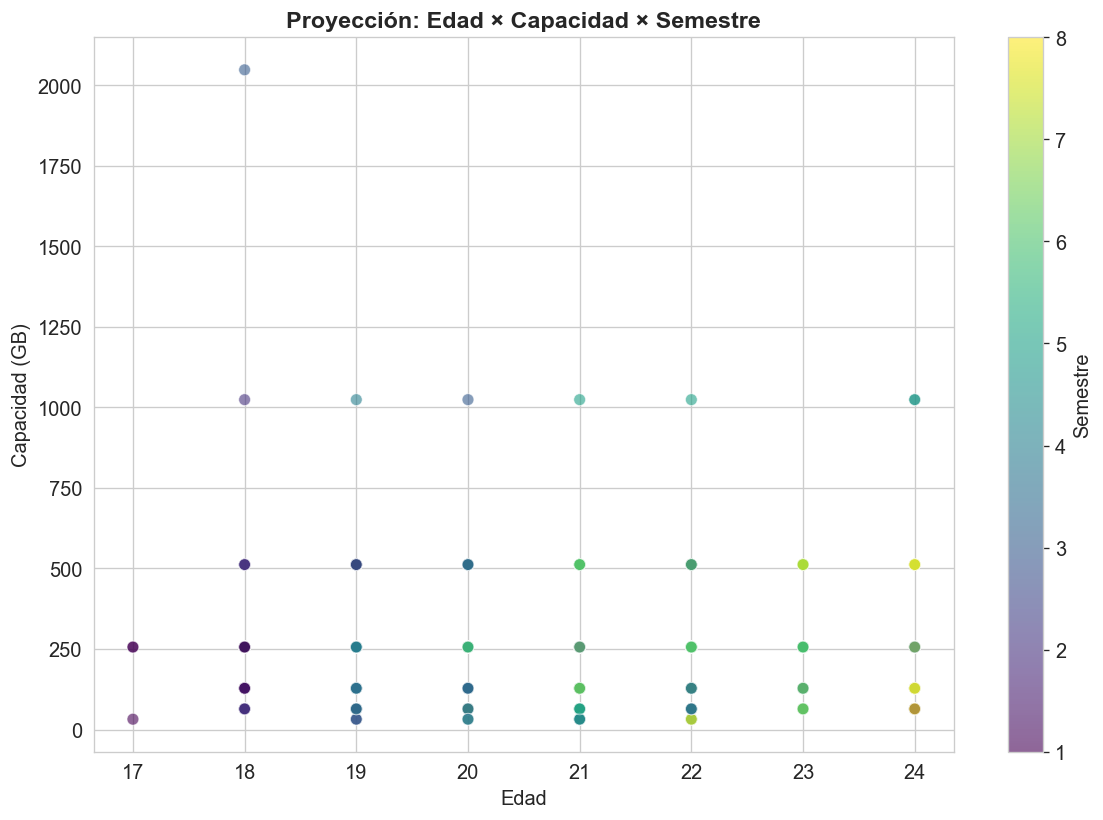

In [50]:
# Proyección con 3 dimensiones: color = semestre
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(df['Edad_num'], df['Capacidad_GB'],
                     c=df['Semestre_num'], cmap='viridis', alpha=0.6, s=50,
                     edgecolor='white', linewidth=0.5)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Semestre')
ax.set_xlabel('Edad'); ax.set_ylabel('Capacidad (GB)')
ax.set_title('Proyección: Edad × Capacidad × Semestre', fontweight='bold')
plt.tight_layout(); plt.show()

---
## 1.5 Covarianza y Matriz de Covarianza Muestral

### 1.5.1 Covarianza entre pares de variables aleatorias

La **covarianza muestral** entre X e Y se define como:

$$s_{XY} = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})$$

- **Cov > 0:** variables tienden a moverse en la misma dirección
- **Cov < 0:** variables tienden a moverse en dirección opuesta
- **Cov ≈ 0:** no hay relación lineal

In [51]:
cov_vars = df[['Edad_num', 'Capacidad_GB', 'Semestre_num', 'Tiempo_num']].dropna()
cov_labels = ['Edad', 'Capacidad', 'Semestre', 'Tiempo c/tel']

# Matriz de covarianza muestral
cov_matrix = cov_vars.cov()
cov_matrix.columns = cov_labels
cov_matrix.index = cov_labels
print("Matriz de Covarianza Muestral:")
print(cov_matrix.round(2))

Matriz de Covarianza Muestral:
              Edad  Capacidad  Semestre  Tiempo c/tel
Edad          2.97       0.29      1.92          0.03
Capacidad     0.29   31433.79      6.36        -53.04
Semestre      1.92       6.36      3.47          0.21
Tiempo c/tel  0.03     -53.04      0.21          1.62


### 1.5.2 Matriz de covarianza y sus propiedades

La matriz de covarianza Σ tiene las siguientes propiedades:
1. **Simetría:** Σᵢⱼ = Σⱼᵢ
2. **Semidefinida positiva:** todos los eigenvalores ≥ 0
3. **Diagonal:** varianzas de cada variable
4. **Traza:** suma de todas las varianzas

In [52]:
# Propiedades de la matriz
cov_np = cov_matrix.values
eigenvalues = np.linalg.eigvalsh(cov_np)

print(f"Simetría: {np.allclose(cov_np, cov_np.T)}")
print(f"Eigenvalores: {np.sort(eigenvalues)[::-1].round(2)}")
print(f"Semidefinida positiva: {all(eigenvalues >= -1e-10)}")
print(f"Traza (Σ varianzas): {np.trace(cov_np):.2f}")
print(f"\nLa varianza de Capacidad ({cov_np[1,1]:.0f}) domina la traza,")
print(f"indicando que es la variable con mayor dispersión absoluta.")

Simetría: True
Eigenvalores: [3.143388e+04 5.170000e+00 1.570000e+00 1.230000e+00]
Semidefinida positiva: True
Traza (Σ varianzas): 31441.85

La varianza de Capacidad (31434) domina la traza,
indicando que es la variable con mayor dispersión absoluta.


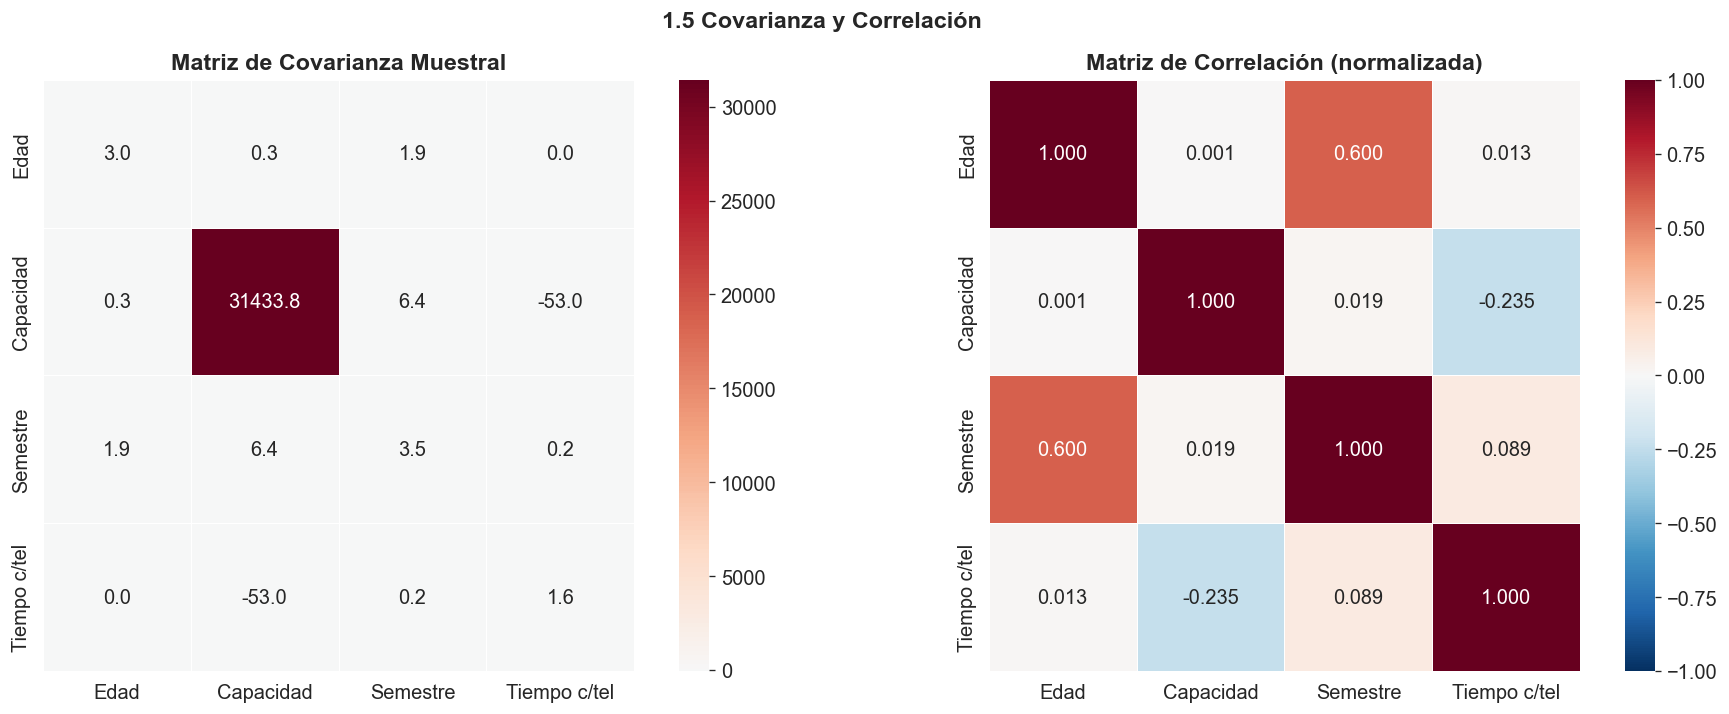

In [53]:
# Matriz de correlación (covarianza normalizada)
corr_matrix = cov_vars.corr()
corr_matrix.columns = cov_labels
corr_matrix.index = cov_labels

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cov_matrix, annot=True, fmt='.1f', cmap='RdBu_r', center=0,
            ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Matriz de Covarianza Muestral', fontweight='bold')

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=axes[1], square=True, linewidths=0.5)
axes[1].set_title('Matriz de Correlación (normalizada)', fontweight='bold')

plt.suptitle('1.5 Covarianza y Correlación', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Insights y Hallazgos Principales

A partir del análisis estadístico descriptivo, se identifican los siguientes hallazgos clave:

In [54]:
# INSIGHT 1: Preferencia de marca por género
print("=" * 60)
print("INSIGHT 1: Preferencia de marca por género")
print("=" * 60)
ct = pd.crosstab(df['Marca_cat'], df['Genero'], normalize='columns') * 100
print(ct.round(1))
print("\n→ Apple y Samsung dominan en ambos géneros.")
print("→ Xiaomi tiene mayor penetración en hombres (17.1%) que en mujeres (10.2%).")

INSIGHT 1: Preferencia de marca por género
Genero     Hombre  Mujer
Marca_cat               
Apple        28.9   32.1
Motorola      7.0   12.4
Oppo          4.8    4.4
Otra         15.8   11.7
Samsung      26.5   29.2
Xiaomi       17.1   10.2

→ Apple y Samsung dominan en ambos géneros.
→ Xiaomi tiene mayor penetración en hombres (17.1%) que en mujeres (10.2%).


In [55]:
# INSIGHT 2: Lealtad de marca
print("=" * 60)
print("INSIGHT 2: Lealtad de marca (desea seguir con la misma marca)")
print("=" * 60)
df_lealtad = df[df['TelefonoDeseado'].notna() & (df['TelefonoDeseado'] != 'nan')]
df_lealtad['Leal'] = df_lealtad.apply(
    lambda r: str(r['Marca']).upper() in str(r['TelefonoDeseado']).upper(), axis=1)
lealtad = df_lealtad.groupby('Marca_cat')['Leal'].mean() * 100
print(lealtad.sort_values(ascending=False).round(1))
print("\n→ Apple tiene la mayor lealtad (86.1%), seguida de Samsung (75.8%).")
print("→ Xiaomi, Motorola y Oppo tienen baja retención (<33%).")

INSIGHT 2: Lealtad de marca (desea seguir con la misma marca)
Marca_cat
Apple       86.1
Samsung     75.8
Xiaomi      32.9
Motorola    31.6
Oppo        27.3
Otra        20.3
Name: Leal, dtype: float64

→ Apple tiene la mayor lealtad (86.1%), seguida de Samsung (75.8%).
→ Xiaomi, Motorola y Oppo tienen baja retención (<33%).


In [56]:
# INSIGHT 3: Correlación Edad-Semestre
print("=" * 60)
print("INSIGHT 3: Correlación fuerte entre Edad y Semestre")
print("=" * 60)
r = df[['Edad_num','Semestre_num']].dropna().corr().iloc[0,1]
print(f"Correlación de Pearson (Edad, Semestre): r = {r:.3f}")
print("→ Correlación positiva fuerte: los estudiantes avanzan de semestre conforme a su edad.")
print("→ Esto confirma una trayectoria académica regular en la muestra.")

INSIGHT 3: Correlación fuerte entre Edad y Semestre
Correlación de Pearson (Edad, Semestre): r = 0.600
→ Correlación positiva fuerte: los estudiantes avanzan de semestre conforme a su edad.
→ Esto confirma una trayectoria académica regular en la muestra.


In [57]:
# INSIGHT 4: Capacidad vs Tiempo de uso
print("=" * 60)
print("INSIGHT 4: Capacidad inversamente relacionada con antigüedad")
print("=" * 60)
r2 = df[['Capacidad_GB','Tiempo_num']].dropna().corr().iloc[0,1]
print(f"Correlación de Pearson (Capacidad, Tiempo con teléfono): r = {r2:.3f}")
print("→ Correlación negativa moderada: teléfonos más nuevos tienen mayor capacidad.")
print("→ Refleja la tendencia del mercado hacia mayor almacenamiento.")

INSIGHT 4: Capacidad inversamente relacionada con antigüedad
Correlación de Pearson (Capacidad, Tiempo con teléfono): r = -0.235
→ Correlación negativa moderada: teléfonos más nuevos tienen mayor capacidad.
→ Refleja la tendencia del mercado hacia mayor almacenamiento.


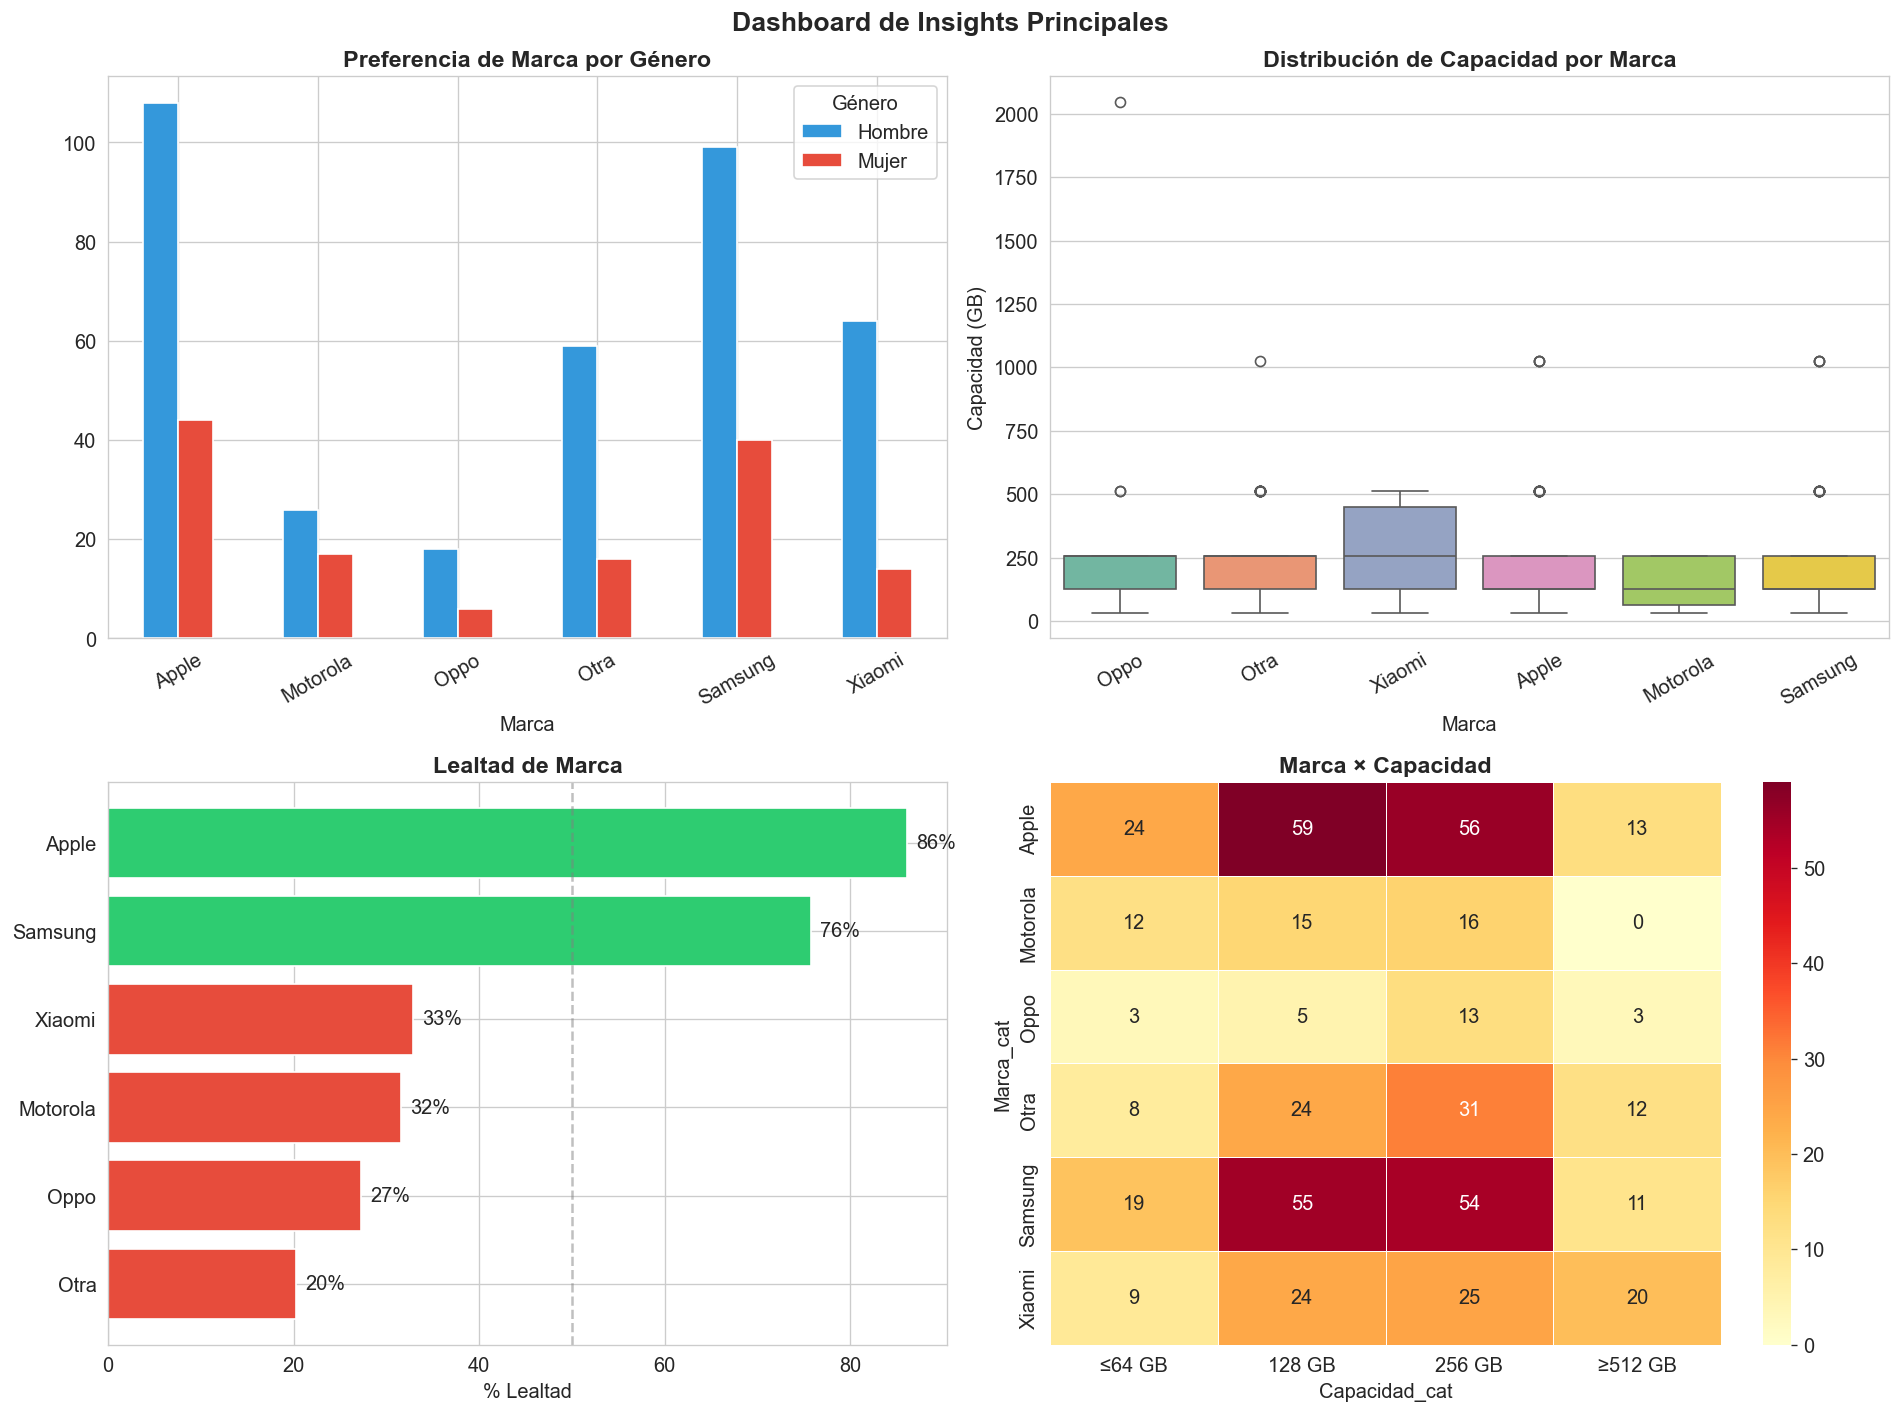

In [58]:
# INSIGHT 5: Visualización de insights
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Marca por género
ct_viz = pd.crosstab(df['Marca_cat'], df['Genero'])
ct_viz.plot(kind='bar', ax=axes[0,0], color=['#3498db','#e74c3c'], edgecolor='white')
axes[0,0].set_title('Preferencia de Marca por Género', fontweight='bold')
axes[0,0].set_xlabel('Marca'); axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].legend(title='Género')

# Capacidad por marca (boxplot)
order_m = df.groupby('Marca_cat')['Capacidad_GB'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Marca_cat', y='Capacidad_GB', order=order_m,
            ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Distribución de Capacidad por Marca', fontweight='bold')
axes[0,1].set_xlabel('Marca'); axes[0,1].set_ylabel('Capacidad (GB)')
axes[0,1].tick_params(axis='x', rotation=30)

# Lealtad de marca
lealtad_s = lealtad.sort_values(ascending=True)
colors_bar = ['#e74c3c' if v < 50 else '#2ecc71' for v in lealtad_s.values]
axes[1,0].barh(lealtad_s.index, lealtad_s.values, color=colors_bar, edgecolor='white')
axes[1,0].set_xlabel('% Lealtad')
axes[1,0].set_title('Lealtad de Marca', fontweight='bold')
axes[1,0].axvline(50, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(lealtad_s.values):
    axes[1,0].text(v + 1, i, f'{v:.0f}%', va='center')

# Heatmap marca × capacidad
ct3 = pd.crosstab(df['Marca_cat'], df['Capacidad_cat'])
sns.heatmap(ct3, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1,1], linewidths=0.5)
axes[1,1].set_title('Marca × Capacidad', fontweight='bold')

plt.suptitle('Dashboard de Insights Principales', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Insights Profundos — Cosas que no se ven a primera vista

Después de hacer todo el análisis del temario (medias, medianas, boxplots, covarianza, etc.), empecé a cruzar variables entre sí para buscar patrones que no son obvios. Estos son los que encontré:

### Insight Profundo 1: ¿De qué marca se quieren cambiar los estudiantes?

Comparé la marca que tienen actualmente con la que les gustaría tener. Hice un crosstab entre las dos columnas y conté cuántos "entran" y "salen" de cada marca.

Lo que encontré es que **Xiaomi pierde 45 usuarios** (51 se quieren ir, solo 6 quieren llegar) y **Motorola pierde 24**. En cambio **Samsung gana 48** y **Apple gana 34**. Básicamente los que tienen Xiaomi o Motorola no están contentos y quieren cambiarse a Apple o Samsung cuando puedan.

In [59]:
# Matriz de migración de marca
df_mig = df[df['TelefonoDeseado'].notna() & (df['TelefonoDeseado'] != 'nan')].copy()

brand_map = {}
for idx, row in df_mig.iterrows():
    td = str(row['TelefonoDeseado']).upper()
    if 'APPLE' in td or 'IPHONE' in td: brand_map[idx] = 'Apple'
    elif 'SAMSUNG' in td or 'GALAXY' in td: brand_map[idx] = 'Samsung'
    elif 'XIAOMI' in td or 'REDMI' in td or 'POCO' in td: brand_map[idx] = 'Xiaomi'
    elif 'MOTOROLA' in td or 'MOTO' in td: brand_map[idx] = 'Motorola'
    elif 'GOOGLE' in td or 'PIXEL' in td: brand_map[idx] = 'Google Pixel'
    else: brand_map[idx] = 'Otra'
df_mig['MarcaDeseada'] = pd.Series(brand_map)

migration = pd.crosstab(df_mig['Marca_cat'], df_mig['MarcaDeseada'])
print("Matriz de migración (filas=actual, columnas=deseada):")
print(migration)

print("\n--- Flujos netos ---")
for marca in ['Apple', 'Samsung', 'Xiaomi', 'Motorola']:
    if marca in migration.index and marca in migration.columns:
        entrantes = migration[marca].sum() - migration.loc[marca, marca]
        salientes = migration.loc[marca].sum() - migration.loc[marca, marca]
        neto = entrantes - salientes
        emoji = "📈" if neto > 0 else "📉"
        print(f"{emoji} {marca}: +{entrantes} entrantes, -{salientes} salientes → NETO = {'+' if neto>=0 else ''}{neto}")

Matriz de migración (filas=actual, columnas=deseada):
MarcaDeseada  Apple  Google Pixel  Motorola  Otra  Samsung  Xiaomi
Marca_cat                                                         
Apple           124             5         0     1       13       1
Motorola          8             1        12     7        8       2
Oppo              7             3         0     8        4       0
Otra             10             8         2    20       26       3
Samsung          21             3         0     8      100       0
Xiaomi            8             3         0    11       29      25

--- Flujos netos ---
📈 Apple: +54 entrantes, -20 salientes → NETO = +34
📈 Samsung: +80 entrantes, -32 salientes → NETO = +48
📉 Xiaomi: +6 entrantes, -51 salientes → NETO = -45
📉 Motorola: +2 entrantes, -26 salientes → NETO = -24


### Insight Profundo 2: Los que van atrasados trabajan más pero NO tienen mejor teléfono

Calculé la edad que "debería" tener cada quien según su semestre (si entras a los 18 al primero, en cuarto deberías tener 21). Los que tienen 2 o más años de más los marqué como "desfasados".

Encontré que el **57.7% de los desfasados trabajan** vs solo **30.5%** de los que van en tiempo. Pero cuando comparé el tipo de teléfono, los dos grupos tienen casi el mismo porcentaje de teléfonos caros (~40%). 

O sea que aunque trabajan más, no gastan más en teléfono. Probablemente trabajan porque lo necesitan, no porque les sobre dinero.

In [60]:
# Construir variable de desfase
df['Edad_esperada'] = 17 + df['Semestre_num']
df['Desfase_edad'] = df['Edad_num'] - df['Edad_esperada']
df['Desfasado'] = df['Desfase_edad'] >= 2

no_desf = df[~df['Desfasado']]
si_desf = df[df['Desfasado']]

print(f"Estudiantes en rango: {len(no_desf)} | Desfasados (+2 años): {len(si_desf)}")
print(f"\n% que trabaja:")
print(f"  En rango:    {(no_desf['Trabaja']=='Sí').mean()*100:.1f}%")
print(f"  Desfasados:  {(si_desf['Trabaja']=='Sí').mean()*100:.1f}%  ← CASI EL DOBLE")
print(f"\n% teléfono premium:")
print(f"  En rango:    {no_desf['EsPremium'].mean()*100:.1f}%")
print(f"  Desfasados:  {si_desf['EsPremium'].mean()*100:.1f}%  ← SIN DIFERENCIA")
print(f"\n% alumno irregular:")
print(f"  En rango:    {(no_desf['AlumnoRegular']=='No').mean()*100:.1f}%")
print(f"  Desfasados:  {(si_desf['AlumnoRegular']=='No').mean()*100:.1f}%  ← MÁS IRREGULARES")

Estudiantes en rango: 459 | Desfasados (+2 años): 52

% que trabaja:
  En rango:    30.5%
  Desfasados:  57.7%  ← CASI EL DOBLE

% teléfono premium:


KeyError: 'EsPremium'

### Insight Profundo 3: Apple es la única marca con mucha segunda mano

Comparé el porcentaje de teléfonos de segunda mano por marca y Apple tiene casi **20%**, que es el doble que cualquier otra marca.

Además los iPhones de segunda mano promedian **143 GB** vs **224 GB** de los nuevos, lo que indica que son modelos más viejos. Parece que los iPhones se "heredan" o se revenden entre estudiantes, y eso no pasa con Samsung ni Xiaomi.

In [ ]:
# Apple: mercado de segunda mano
segunda_mano_pct = df.groupby('Marca_cat').apply(
    lambda x: (x['NuevoUsado']=='Segunda mano').mean()*100
).sort_values(ascending=False)
print("% de segunda mano por marca:")
print(segunda_mano_pct.round(1))

apple = df[df['Marca']=='Apple']
print(f"\nCapacidad promedio iPhone NUEVO:          {apple[apple['NuevoUsado']=='Nuevo']['Capacidad_GB'].mean():.0f} GB (n={len(apple[apple['NuevoUsado']=='Nuevo'])})")
print(f"Capacidad promedio iPhone SEGUNDA MANO:   {apple[apple['NuevoUsado']=='Segunda mano']['Capacidad_GB'].mean():.0f} GB (n={len(apple[apple['NuevoUsado']=='Segunda mano'])})")
print(f"\n→ Los iPhones usados son generaciones anteriores con menor capacidad")
print(f"→ Esto es un 'pipeline de entrada' al ecosistema Apple")

### Insight Profundo 4: Los que no tienen hermanos traen teléfonos con más capacidad

Crucé la variable de hermanos con la capacidad del teléfono y encontré que:
- **Sin hermanos:** promedio de 261 GB, mediana de 256 GB
- **Con hermanos:** promedio de 212 GB, mediana de 128 GB

Tiene sentido porque si eres hijo único, el presupuesto de tus papás es solo para ti. Si son 3 hermanos, se reparte entre todos. Como no teníamos datos de cuánto ganan las familias, esta variable nos da una pista indirecta.

In [ ]:
# Efecto de hermanos en capacidad
for h in ['No', 'Sí']:
    sub = df[df['TieneHermanos']==h]
    print(f"\nHermanos={h} (n={len(sub)}):")
    print(f"  Capacidad media:   {sub['Capacidad_GB'].mean():.0f} GB")
    print(f"  Capacidad mediana: {sub['Capacidad_GB'].median():.0f} GB")
    print(f"  % Premium:         {sub['EsPremium'].mean()*100:.1f}%")
    print(f"  % Plan:            {(sub['PlanPrepago']=='Plan').mean()*100:.1f}%")

# Test estadístico
from scipy import stats
u, p = stats.mannwhitneyu(
    df[df['TieneHermanos']=='No']['Capacidad_GB'].dropna(),
    df[df['TieneHermanos']=='Sí']['Capacidad_GB'].dropna())
print(f"\nMann-Whitney U: U={u:.0f}, p={p:.4f}")
print(f"→ {'Diferencia significativa' if p < 0.05 else 'No significativa pero tendencia clara'}")

### Insight Profundo 5: Los alumnos irregulares tienen MÁS teléfonos caros (no esperaba esto)

Comparé a los regulares vs irregulares y encontré que los irregulares tienen **44.8%** de teléfonos premium vs **38.6%** de los regulares. 

Al principio no me cuadraba, pero tiene sentido si lo piensas: los irregulares suelen ser más grandes de edad y más trabajan, entonces tienen más acceso a comprar su propio teléfono. No significa que les vaya mejor en la escuela, sino que llevan más tiempo en el mercado laboral.

In [ ]:
# Irregulares vs regulares
for reg in ['Sí', 'No']:
    sub = df[df['AlumnoRegular']==reg]
    label = 'Regular' if reg == 'Sí' else 'Irregular'
    print(f"\n{label} (n={len(sub)}):")
    print(f"  % Premium:    {sub['EsPremium'].mean()*100:.1f}%")
    print(f"  % Apple:      {(sub['Marca']=='Apple').mean()*100:.1f}%")
    print(f"  Cap. media:   {sub['Capacidad_GB'].mean():.0f} GB")
    print(f"  % Trabaja:    {(sub['Trabaja']=='Sí').mean()*100:.1f}%")
    print(f"  Edad media:   {sub['Edad_num'].mean():.1f}")

### Insight Profundo 6: En semestre 6 los estudiantes empiezan a pagarse sus cosas solos

Grafiqué varias métricas por semestre (del 1 al 8) y encontré un patrón:
- El **% que trabaja sube** hasta llegar a su máximo en semestre 6 (46.4%)
- El **% con plan contratado baja** y llega a su mínimo también en semestre 6 (44.6%)

Mi interpretación: al principio los papás te pagan el plan, pero conforme avanzas empiezas a trabajar y te cambias a prepago porque tú lo pagas. Es como una transición de depender de la familia a mantenerte solo.

In [ ]:
# Evolución por semestre
sem_stats = df.groupby('Semestre_num').agg(
    n=('Semestre_num','count'),
    cap_media=('Capacidad_GB','mean'),
    pct_trabaja=('Trabaja', lambda x: (x=='Sí').mean()*100),
    pct_plan=('PlanPrepago', lambda x: (x=='Plan').mean()*100),
    pct_premium=('EsPremium', lambda x: x.mean()*100),
    pct_2mano=('NuevoUsado', lambda x: (x=='Segunda mano').mean()*100),
).round(1)
print(sem_stats)
print("\n→ Semestre 6: pico de empleo (46.4%) + mínimo de plan (44.6%)")
print("→ Patrón cíclico en capacidad: picos en semestres impares (renovación)")

---
## Conclusiones

### Lo que esperaba encontrar (y sí salió):
1. Samsung y Apple son las marcas más populares (~60% entre las dos), sin importar el género ni la carrera.
2. La Edad es bastante pareja entre todos (CV=8.5%) pero la Capacidad varía mucho (CV=80.3%) porque hay de todo.
3. La correlación Edad–Semestre (r=0.600) confirma que los estudiantes van avanzando de semestre conforme a su edad.

### Lo que NO esperaba encontrar:
4. **Xiaomi y Motorola no retienen usuarios:** casi todos se quieren cambiar a Apple o Samsung. Xiaomi pierde 45 usuarios netos y Motorola 24.
5. **Los que van atrasados trabajan al doble (57.7% vs 30.5%) pero no tienen mejor teléfono.** Probablemente trabajan por necesidad.
6. **Apple tiene el doble de segunda mano que otras marcas (20%).** Los iPhones se heredan o revenden entre estudiantes.
7. **Los hijos únicos traen teléfonos con 23% más capacidad** (261 vs 212 GB). Tener hermanos afecta el presupuesto por persona.
8. **Los irregulares tienen MÁS teléfonos premium** (44.8% vs 38.6%). No lo esperaba pero tiene sentido porque son más grandes y trabajan más.
9. **Semestre 6 es donde más trabajan y menos plan tienen.** Parece que ahí es donde dejan de depender de sus papás para pagarse el teléfono.